In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
sns.set(style="whitegrid", font_scale=1.2)
df = pd.read_csv("logs/New_folder/spread2_result_episodes.csv")
df.head()

,model_name,episode,gamma_hedge_ratio,vega_hedge_ratio,total_pnl,total_hed_cost
0,11600.pth_weightedmean,0,0.091845,0.033136,2.495628,-3.621038
1,11600.pth_weightedmean,1,0.160031,0.051451,12.752237,-6.037986
2,11600.pth_weightedmean,2,0.098103,0.019180,-21.349846,-9.523574
3,11600.pth_weightedmean,3,0.204797,0.100447,3.742393,-4.791237
4,11600.pth_weightedmean,4,0.283436,0.015820,-13.680939,-8.293681


In [44]:
def pnl_statistics(x):
    return pd.Series({
        "mean": x.mean(),
        "std": x.std(),
        "skewness": skew(x),
        "kurtosis": kurtosis(x, fisher=True),  # Fisher = excess kurtosis
        "VaR_5%": np.percentile(x, 5),
        "CVaR_5%": x[x <= np.percentile(x, 5)].mean()
    })

In [69]:
models_to_analyze = ["35000.pth_meanstd","15400.pth_cvar","11600.pth_weightedmean","27800.pth_var","18400.pth_meanvar",'Delta_agent', 'Gamma_agent','Vega_agent',"no_hedging"]
df_filtered = df[df["model_name"].isin(models_to_analyze)]
stats_by_model = (
    df_filtered
    .groupby("model_name")["total_pnl"]
    .apply(pnl_statistics)
    .unstack()
)
stats_by_model

,mean,std,skewness,kurtosis,VaR_5%,CVaR_5%
model_name,,,,,,
11600.pth_weightedmean,-4.714118,12.784550,-0.435874,3.591303,-25.381703,-35.210129
15400.pth_cvar,-4.996601,11.945695,-0.419152,2.968037,-24.890271,-33.167249
18400.pth_meanvar,-6.158437,12.442627,-0.196312,3.388691,-26.414199,-34.832971
27800.pth_var,-6.134196,12.028208,-0.523656,3.858013,-26.160614,-35.004040
35000.pth_meanstd,-5.235220,11.985955,-0.366234,3.158323,-24.785887,-33.354311
Delta_agent,0.321147,21.783420,-0.067354,3.718618,-34.424025,-51.009072
Gamma_agent,-13.793927,10.148536,-0.905974,6.633275,-30.762037,-39.312792
Vega_agent,-26.163039,23.573779,-0.259319,5.435745,-63.842643,-85.886503
no_hedging,-2.529575,218.769645,-0.799596,6.844328,-334.377718,-564.417049


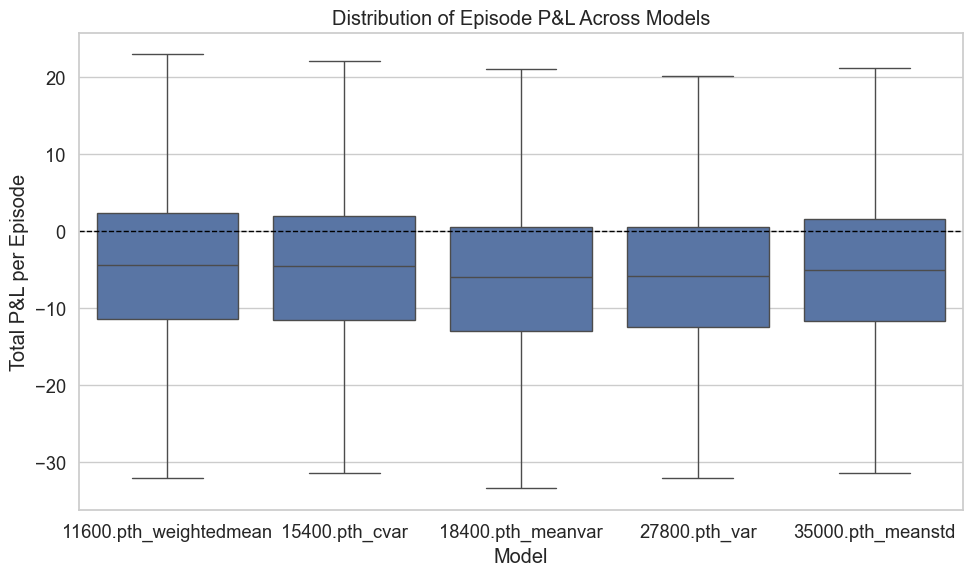

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_filtered,
    x="model_name",
    y="total_pnl",
    showfliers=False  # 去掉极端 outlier，更清晰
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of Episode P&L Across Models")
plt.xlabel("Model")
plt.ylabel("Total P&L per Episode")

plt.tight_layout()
plt.show()

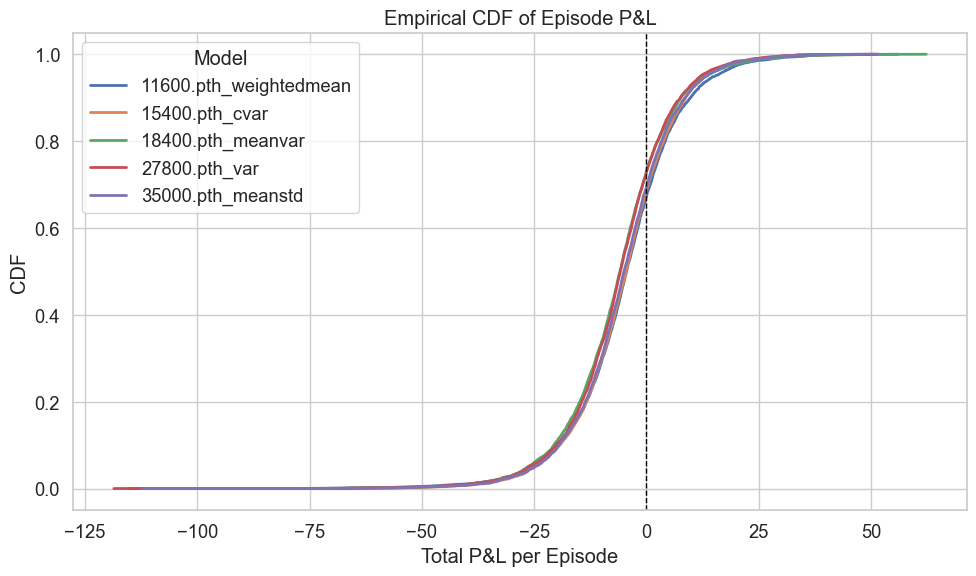

In [18]:
plt.figure(figsize=(10, 6))

for model, g in df_filtered.groupby("model_name"):
    x = np.sort(g["total_pnl"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=model, linewidth=2)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Empirical CDF of Episode P&L")
plt.xlabel("Total P&L per Episode")
plt.ylabel("CDF")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

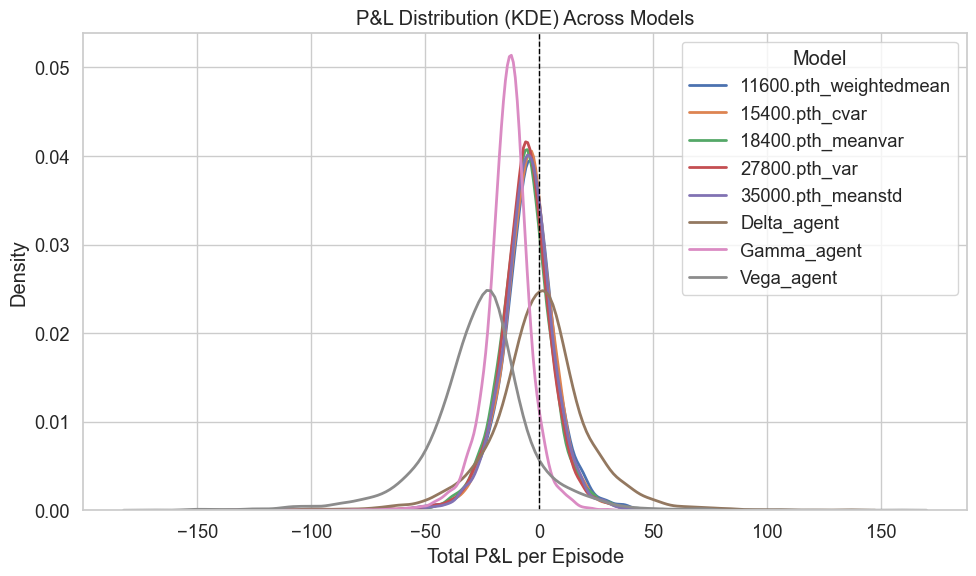

In [38]:
plt.figure(figsize=(10, 6))

for model, g in df_filtered.groupby("model_name"):
    sns.kdeplot(
        g["total_pnl"],
        label=model,
        linewidth=2
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("P&L Distribution (KDE) Across Models")
plt.xlabel("Total P&L per Episode")
plt.ylabel("Density")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

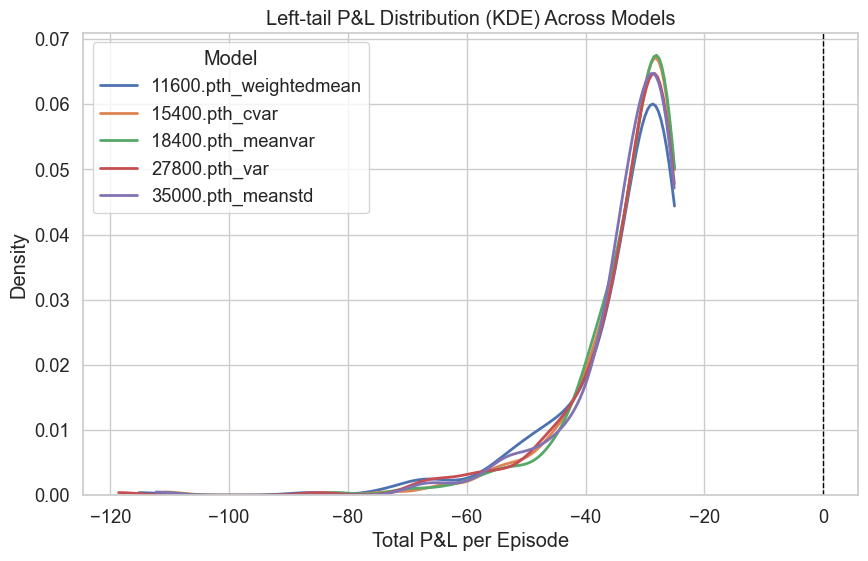

In [24]:
threshold = -25  # 只看 P&L < 0 的部分
df_left = df_filtered[df_filtered["total_pnl"] < threshold]

plt.figure(figsize=(10,6))
for model, g in df_left.groupby("model_name"):
    sns.kdeplot(
    g["total_pnl"],
    label=model,
    linewidth=2,
    clip=(-np.inf, threshold),
    cut=0
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Left-tail P&L Distribution (KDE) Across Models")
plt.xlabel("Total P&L per Episode")
plt.ylabel("Density")
plt.legend(title="Model")
plt.show()

In [20]:
df_filtered.groupby("model_name")["total_pnl"].describe()

,count,mean,std,min,25%,50%,75%,max
model_name,,,,,,,,
11600.pth_weightedmean,5000.0,-4.714118,12.784550,-115.169870,-11.339589,-4.410835,2.413848,56.007818
15400.pth_cvar,5000.0,-4.996601,11.945695,-110.891685,-11.485984,-4.531717,1.993603,51.956502
18400.pth_meanvar,5000.0,-6.158437,12.442627,-111.268492,-12.992287,-5.882112,0.634340,62.309765
27800.pth_var,5000.0,-6.134196,12.028208,-118.597965,-12.407034,-5.813966,0.638469,50.708830
35000.pth_meanstd,5000.0,-5.235220,11.985955,-112.312707,-11.643795,-4.995298,1.576462,51.397334


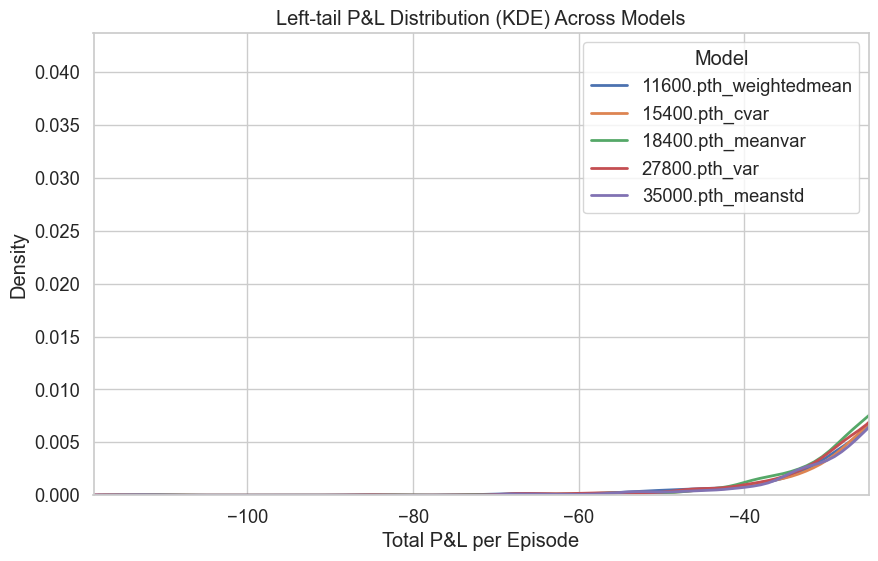

In [22]:
plt.figure(figsize=(10,6))
for model, g in df_filtered.groupby("model_name"):
    sns.kdeplot(
        g["total_pnl"],
        label=model,
        linewidth=2
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlim(df_filtered["total_pnl"].min(), -25)  # 只显示 P&L ≤ 0
plt.title("Left-tail P&L Distribution (KDE) Across Models")
plt.xlabel("Total P&L per Episode")
plt.ylabel("Density")
plt.legend(title="Model")
plt.show()

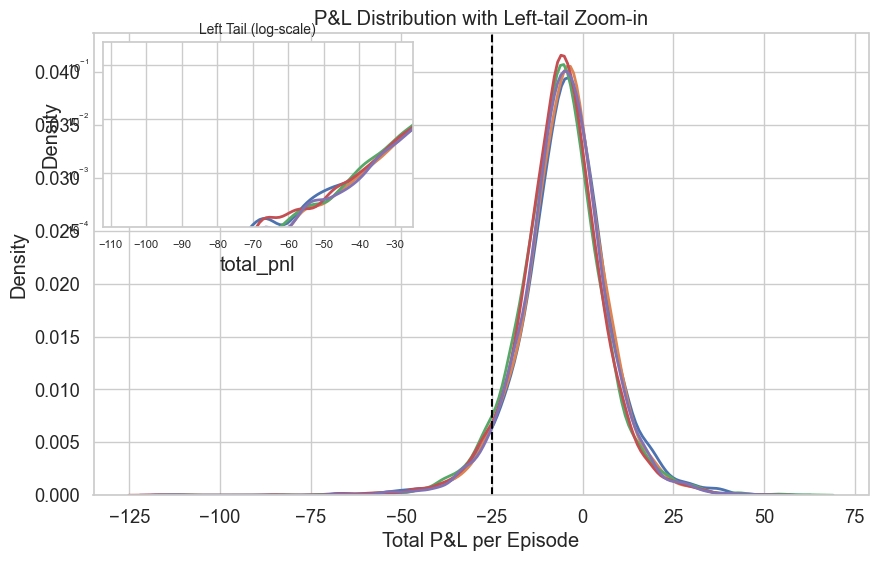

In [32]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
threshold = -25

fig, ax = plt.subplots(figsize=(10,6))

# 主图：完整 KDE
for model, g in df_filtered.groupby("model_name"):
    sns.kdeplot(
        g["total_pnl"],
        ax=ax,
        label=model,
        linewidth=2
    )

ax.axvline(threshold, color="black", linestyle="--")
ax.set_title("P&L Distribution with Left-tail Zoom-in")
ax.set_xlabel("Total P&L per Episode")
ax.set_ylabel("Density")
ax.legend(title="Model")

# inset：左尾放大
ax_inset = inset_axes(ax, width="40%", height="40%", loc="upper left")

for model, g in df_filtered.groupby("model_name"):
    sns.kdeplot(
        g["total_pnl"],
        ax=ax_inset,
        linewidth=2,
        bw_adjust=1.3
    )

ax_inset.set_xlim(g["total_pnl"].min(), threshold)
ax_inset.set_yscale("log") 
ax_inset.set_ylim(1e-4, None)       # 👈 防止贴地
ax_inset.set_title("Left Tail (log-scale)", fontsize=10)
ax_inset.tick_params(labelsize=8)

plt.show()